# Saturation flag demo

Demonstrates the detector **saturation flag** (ADU clip).

A source saturates when its **brightest pixel** reaches the detector ADC full scale
(`adc_max = 2**bit_depth - 1`, in ADU). The peak-pixel value combines the source PSF
peak, the per-pixel sky background, the per-pixel dark current, and the additive bias.

Key API:
- `sensor.bit_depth`, `sensor.bias_level`, `sensor.adc_max`
- `sim.psf_profile['peak_pixel_fraction']` &mdash; fraction of total source energy in the brightest pixel
- `sim.get_peak_pixel(time, units='adu')`
- `sim.is_saturated(time)`

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u

import wcc_etc
wcc_etc.set_wcc_style()

/Users/gudmundurstefansson/Dropbox/mypylib/notebooks/GIT/wcc-etc4/wcc-etc/src/wcc_etc/wcc_etc.py:26: UserWarning: DEPRECATION: wcc_etc.py is deprecated.
  warnings.warn("DEPRECATION: wcc_etc.py is deprecated.")


## Build a scene and simulation

A moderately bright star on the ZWO/Sony sensor (16-bit) in the r band.

In [2]:
scene = wcc_etc.get_scene(name='G5V',
                          mag=15,
                          host=None,
                          background='zodi',
                          bandpass='johnson_r',
                          background_prop={'bandpass': 'johnson_r', 'mag': 22.5})

sim = wcc_etc.Simulation.from_sensor_and_scene('sony:r', scene)

## Sensor ADC properties

`adc_max` is the clip ceiling in ADU (`u.ct`).

In [3]:
print(f'bit_depth  : {sim.sensor.bit_depth}')
print(f'adc_max    : {sim.sensor.adc_max}')
print(f'bias_level : {sim.sensor.bias_level}')
print(f'gain       : {sim.sensor.gain}')

bit_depth  : 16
adc_max    : 65535.0 ct
bias_level : 0.0 ct
gain       : 0.261200000004368 electron / ct


## Peak-pixel fraction

The fraction of the total source energy that lands in the single brightest pixel,
from the detector-grid PSF render. (Depends on wavelength, f-number, pixel size, and jitter.)

In [4]:
frac = sim.psf_profile['peak_pixel_fraction']
print(f'peak_pixel_fraction = {frac:.4f}  ({100*frac:.1f}% of the source flux in the brightest pixel)')

peak_pixel_fraction = 0.1126  (11.3% of the source flux in the brightest pixel)


## Single-exposure check

In [5]:
for t in [1, 10, 60]:
    peak = sim.get_peak_pixel(t, units='adu')
    print(f't = {t:>4} s   peak = {peak.value:12.1f} ADU   saturated = {bool(sim.is_saturated(t))}')

t =    1 s   peak =      15465.7 ADU   saturated = False
t =   10 s   peak =     154657.4 ADU   saturated = True
t =   60 s   peak =     927944.3 ADU   saturated = True


## Sweep exposure time

`get_peak_pixel` and `is_saturated` broadcast over an array of times.

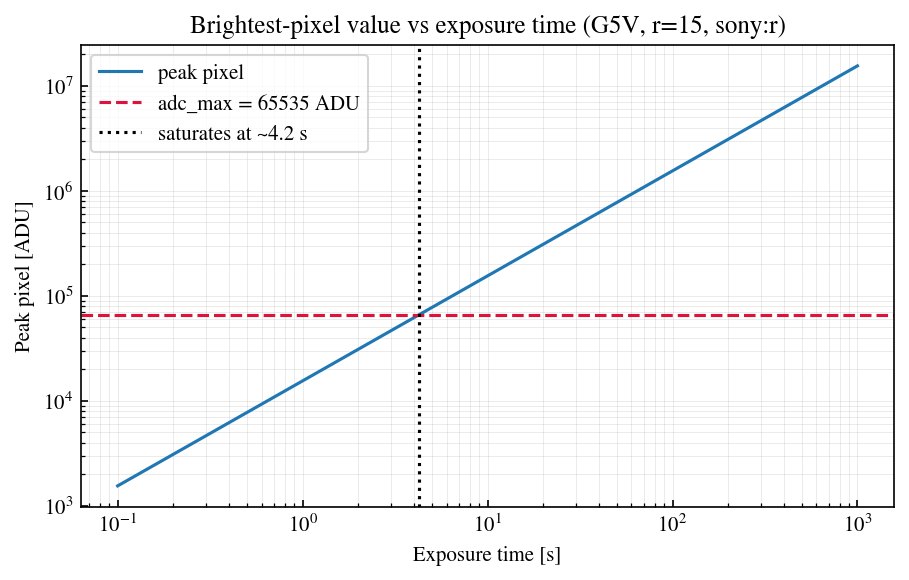

saturates at ~ 4.25 s


In [6]:
texp = np.logspace(-1, 3, 200)  # 0.1 s to 1000 s
peak_adu = sim.get_peak_pixel(texp, units='adu').value
saturated = sim.is_saturated(texp)
adc_max = sim.sensor.adc_max.value

# first exposure time that saturates
t_sat = texp[saturated][0] if saturated.any() else None

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(texp, peak_adu, label='peak pixel')
ax.axhline(adc_max, color='crimson', ls='--', label=f'adc_max = {adc_max:.0f} ADU')
if t_sat is not None:
    ax.axvline(t_sat, color='k', ls=':', label=f'saturates at ~{t_sat:.2g} s')
ax.set_xlabel('Exposure time [s]')
ax.set_ylabel('Peak pixel [ADU]')
ax.set_title('Brightest-pixel value vs exposure time (G5V, r=15, sony:r)')
ax.legend()
ax.grid(True, which='both', lw=0.3, alpha=0.4)
plt.show()

print('saturates at ~ {:.3g} s'.format(t_sat) if t_sat is not None else 'never saturates in this range')

## Effect of source brightness

Brighter stars (lower magnitude) saturate sooner.

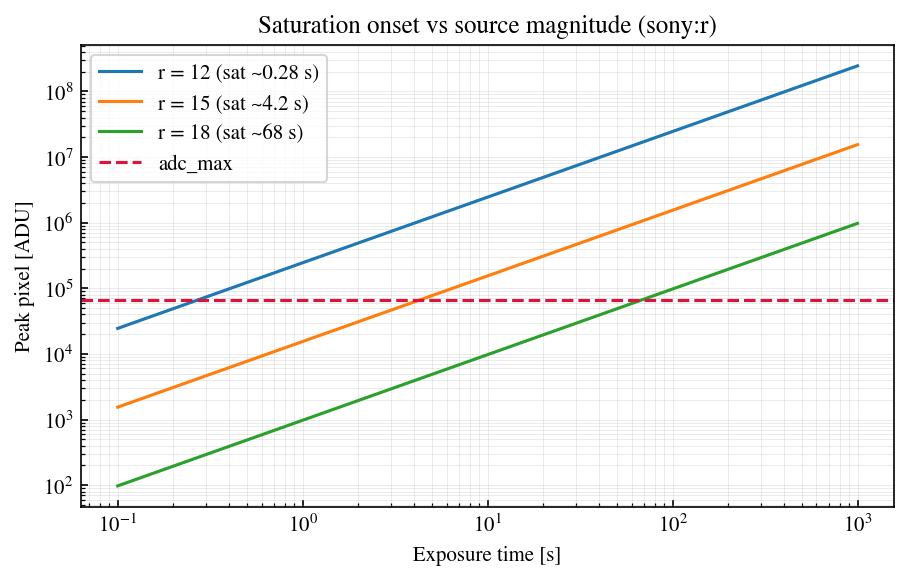

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
for mag in [12, 15, 18]:
    sim.update(source__mag=mag)
    peak = sim.get_peak_pixel(texp, units='adu').value
    sat = sim.is_saturated(texp)
    t_s = texp[sat][0] if sat.any() else None
    label = f'r = {mag}' + (f' (sat ~{t_s:.2g} s)' if t_s is not None else ' (no sat)')
    ax.loglog(texp, peak, label=label)

ax.axhline(adc_max, color='crimson', ls='--', label='adc_max')
ax.set_xlabel('Exposure time [s]')
ax.set_ylabel('Peak pixel [ADU]')
ax.set_title('Saturation onset vs source magnitude (sony:r)')
ax.legend()
ax.grid(True, which='both', lw=0.3, alpha=0.4)
plt.show()

# restore
sim.update(source__mag=15);

## Sensor comparison: 16-bit vs 12-bit

The qcmos sensor is 12-bit (`adc_max = 4095`), so it clips far sooner than the 16-bit ZWO/Sony
for the same source &mdash; lower full-scale, and a different gain.

In [8]:
sim_q = wcc_etc.Simulation.from_sensor_and_scene('qcmos:r', scene)

for label, s in [('sony:r (16-bit)', sim), ('qcmos:r (12-bit)', sim_q)]:
    peak = s.get_peak_pixel(texp, units='adu').value
    sat = s.is_saturated(texp)
    t_s = texp[sat][0] if sat.any() else None
    t_s_str = f'{t_s:.3g} s' if t_s is not None else 'no sat in range'
    print(f'{label:>18}  adc_max = {s.sensor.adc_max.value:7.0f} ADU   saturates at ~ {t_s_str}')

   sony:r (16-bit)  adc_max =   65535 ADU   saturates at ~ 4.25 s


  qcmos:r (12-bit)  adc_max =    4095 ADU   saturates at ~ 0.1 s
